In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv('../.env')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Setup complete")

Setup complete


In [3]:
%pip install -q --upgrade "protobuf>=5.26.1"

from src.rag.embedder import DocumentEmbedder, chunk_text

embedder = DocumentEmbedder()

# Load real news articles
news_df = pd.read_csv('../data/processed/AAPL/news_enriched.csv')
news_df['published_at'] = pd.to_datetime(
    news_df['published_at'], utc=True, errors='coerce'
)

# Take 20 articles as our sample corpus
sample_df    = news_df.dropna(subset=['content']).head(20)
sample_texts = sample_df['content'].fillna('').tolist()
sample_titles = sample_df['title'].fillna('').tolist()

print(f"Sample corpus: {len(sample_texts)} documents")
print(f"\nSample titles:")
for i, title in enumerate(sample_titles[:5], 1):
    print(f"  {i}. {title[:80]}")

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.6 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 7.34.1 which is incompatible.
opentelemetry-proto 1.27.0 requires protobuf<5.0,>=3.19, but you have protobuf 7.34.1 which is incompatible.
streamlit 1.36.0 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


2026-05-13 12:53:54 | INFO     | src.rag.embedder | Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
2026-05-13 12:53:57 | INFO     | src.rag.embedder | Embedder ready | model=sentence-transformers/all-MiniLM-L6-v2 | dim=384


Sample corpus: 20 documents

Sample titles:
  1. Is Apple Stock Back in Style?
  2. The Best Tech Stocks Under $20 to Buy in 2026
  3. Paul Tudor Jones Warns Trump-Era Market Boom Could End in a 35% Crash. Heres Why
  4. Is Intel Stock the Next Nvidia?
  5. Apple dominated the 2026 chip war. Googles partners are left to buy scraps


2026-05-13 12:54:05 | INFO     | src.rag.embedder | Embedding 8 chunks...
2026-05-13 12:54:06 | INFO     | src.rag.embedder | Embeddings shape: (8, 384)


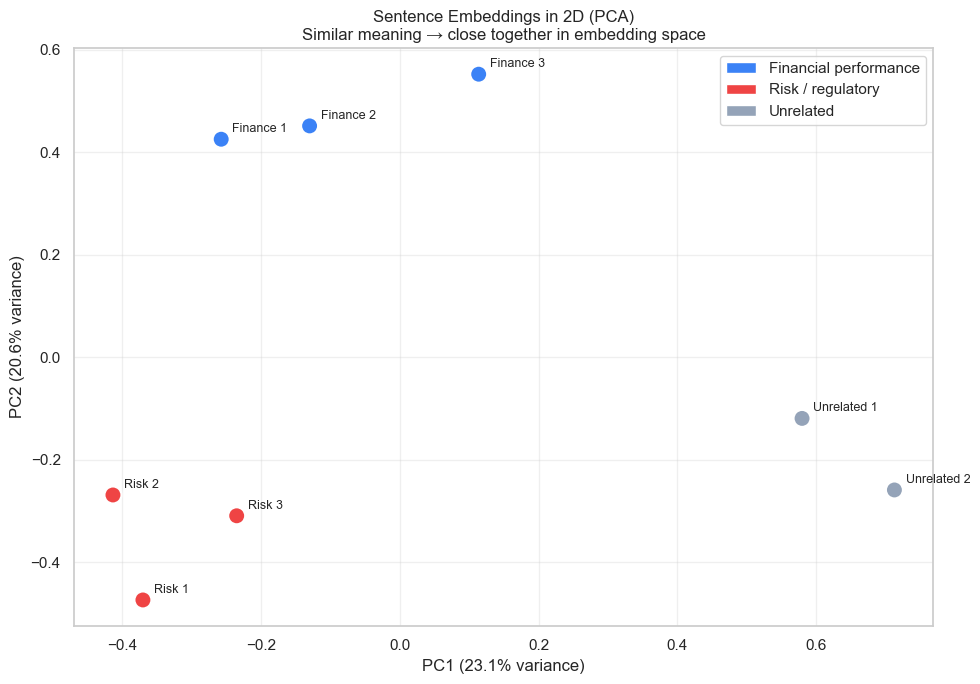

Key insight: Finance sentences cluster together,
Risk sentences cluster together,
Unrelated sentences are far from both groups.

Embedding dimension: 384


In [4]:
# Demonstrate the core concept: similar texts → similar vectors

concept_sentences = [
    # Finance group
    "Apple reported record quarterly revenue beating analyst estimates",
    "iPhone maker exceeded earnings expectations significantly",
    "Strong sales drove profits above Wall Street forecasts",

    # Risk group
    "Apple faces regulatory pressure over App Store policies",
    "Antitrust concerns threaten Apple's business model",
    "Government scrutiny increases for tech giants",

    # Unrelated
    "The weather in San Francisco is foggy today",
    "Recipe for chocolate chip cookies requires butter",
]

labels = [
    "Finance 1", "Finance 2", "Finance 3",
    "Risk 1",    "Risk 2",    "Risk 3",
    "Unrelated 1", "Unrelated 2",
]

colors = [
    "#3b82f6", "#3b82f6", "#3b82f6",   # blue for finance
    "#ef4444", "#ef4444", "#ef4444",   # red for risk
    "#94a3b8", "#94a3b8",              # gray for unrelated
]

# Embed all sentences
embeddings = embedder.embed_documents(concept_sentences, show_progress=False)

# Reduce to 2D with PCA for visualization
from sklearn.decomposition import PCA
pca   = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=colors, s=150, zorder=3, edgecolors='white', linewidths=1.5
)

for i, label in enumerate(labels):
    ax.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
    )

ax.set_title(
    'Sentence Embeddings in 2D (PCA)\n'
    'Similar meaning → close together in embedding space',
    fontsize=12
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3b82f6', label='Financial performance'),
    Patch(facecolor='#ef4444', label='Risk / regulatory'),
    Patch(facecolor='#94a3b8', label='Unrelated'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: Finance sentences cluster together,")
print("Risk sentences cluster together,")
print("Unrelated sentences are far from both groups.")
print(f"\nEmbedding dimension: {embeddings.shape[1]}")

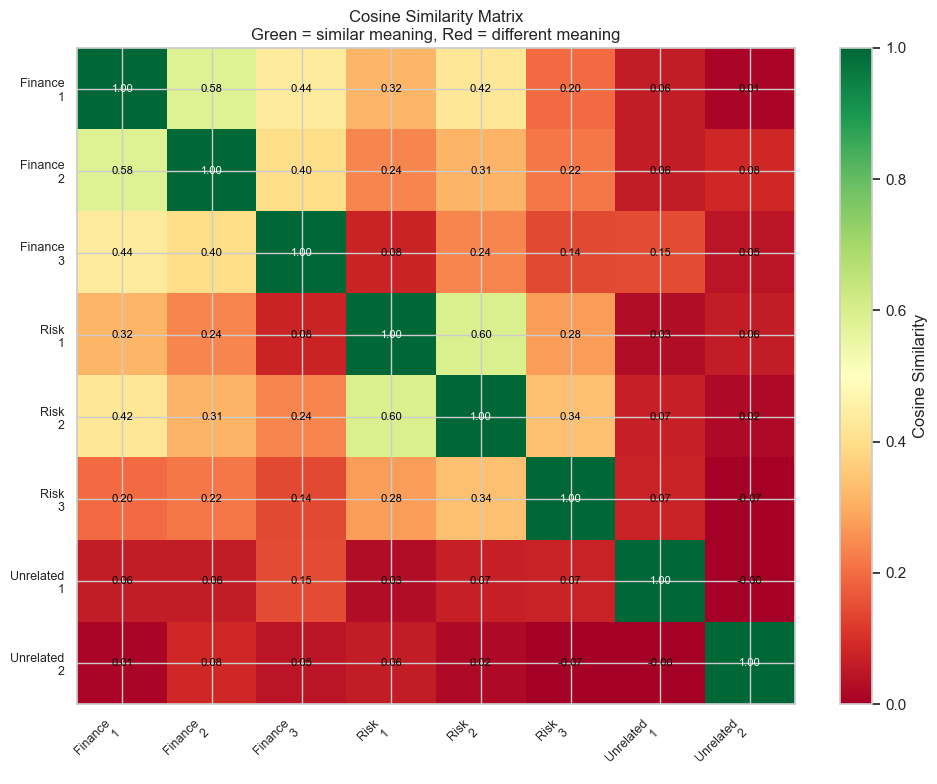


Most similar pair (0.595):
  'Apple faces regulatory pressure over App Store policies'
  'Antitrust concerns threaten Apple's business model'

Least similar pair (-0.072):
  'Government scrutiny increases for tech giants'
  'Recipe for chocolate chip cookies requires butter'


In [5]:
# Show similarity scores between all concept sentences

similarity_matrix = embeddings @ embeddings.T

fig, ax = plt.subplots(figsize=(10, 8))

short_labels = [l.replace(' ', '\n') for l in labels]

im = ax.imshow(
    similarity_matrix,
    cmap   = 'RdYlGn',
    aspect = 'auto',
    vmin   = 0,
    vmax   = 1,
)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

# Annotate cells with scores
for i in range(len(labels)):
    for j in range(len(labels)):
        score = similarity_matrix[i, j]
        color = 'white' if score > 0.7 else 'black'
        ax.text(j, i, f'{score:.2f}', ha='center', va='center',
                fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_title(
    'Cosine Similarity Matrix\n'
    'Green = similar meaning, Red = different meaning',
    fontsize=12
)

plt.tight_layout()
plt.show()

# Highlight the most and least similar pairs
flat_sim = similarity_matrix.copy()
np.fill_diagonal(flat_sim, 0)
max_idx = np.unravel_index(flat_sim.argmax(), flat_sim.shape)
min_idx = np.unravel_index(flat_sim.argmin(), flat_sim.shape)

print(f"\nMost similar pair ({flat_sim[max_idx]:.3f}):")
print(f"  '{concept_sentences[max_idx[0]][:60]}'")
print(f"  '{concept_sentences[max_idx[1]][:60]}'")
print(f"\nLeast similar pair ({flat_sim[min_idx]:.3f}):")
print(f"  '{concept_sentences[min_idx[0]][:60]}'")
print(f"  '{concept_sentences[min_idx[1]][:60]}'")

In [6]:
from src.rag.vector_store import FinancialVectorStore

# Use a separate test collection so we don't pollute the main store
store = FinancialVectorStore(
    persist_dir     = '../data/embeddings',
    collection_name = 'notebook_test',
)

# Embed and store sample articles
texts, embeddings_arr, metadatas = embedder.embed_dataframe(
    df            = sample_df,
    text_col      = 'content',
    metadata_cols = ['ticker', 'source', 'published_at', 'sentiment_label'],
)

if texts:
    ids = [f'test_chunk_{i}' for i in range(len(texts))]
    store.upsert_documents(texts, embeddings_arr, metadatas, ids)

print(f"Vector store ready | {store.count()} chunks stored")

2026-05-13 12:54:24 | INFO     | src.rag.vector_store | Initializing ChromaDB | persist_dir=../data/embeddings
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
2026-05-13 12:54:25 | INFO     | src.rag.vector_store | Vector store ready | collection=notebook_test | documents=0
2026-05-13 12:54:25 | INFO     | src.rag.embedder | Processing 20 documents for embedding...
2026-05-13 12:54:25 | INFO     | src.rag.embedder | Total chunks to embed: 20
2026-05-13 12:54:25 | INFO     | src.rag.embedder | Embedding 20 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-13 12:54:25 | INFO     | src.rag.embedder | Embeddings shape: (20, 384)
2026-05-13 12:54:25 | INFO     | src.rag.vector_store | Upserted 20 chunks


Vector store ready | 20 chunks stored


2026-05-13 12:55:02 | INFO     | src.rag.vector_store | Query returned 3 chunks
2026-05-13 12:55:02 | INFO     | src.rag.vector_store | Query returned 3 chunks
2026-05-13 12:55:02 | INFO     | src.rag.vector_store | Query returned 3 chunks
2026-05-13 12:55:02 | INFO     | src.rag.vector_store | Query returned 3 chunks
2026-05-13 12:55:02 | INFO     | src.rag.vector_store | Query returned 3 chunks


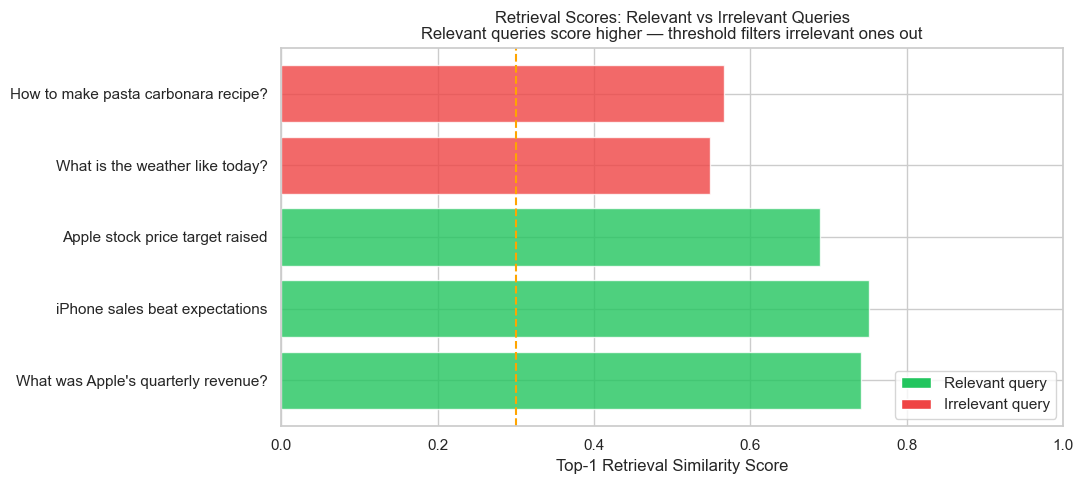


Key insight: Relevant queries score above 0.3 threshold.
Irrelevant queries score below — correctly filtered out.


In [8]:
# Show how similarity scores change with query relevance

queries_scored = [
    ("What was Apple's quarterly revenue?",    "Relevant"),
    ("iPhone sales beat expectations",          "Relevant"),
    ("Apple stock price target raised",         "Relevant"),
    ("What is the weather like today?",         "Irrelevant"),
    ("How to make pasta carbonara recipe?",     "Irrelevant"),
]

query_labels  = []
top_scores    = []
relevance     = []

for query, rel in queries_scored:
    q_emb    = embedder.embed_query(query)
    raw      = store.query(q_emb, top_k=3)
    chunks   = store.format_results(raw)

    if chunks:
        top_score = chunks[0]['similarity']
    else:
        top_score = 0.0

    query_labels.append(query[:45] + '..' if len(query) > 45 else query)
    top_scores.append(top_score)
    relevance.append(rel)

colors = ['#22c55e' if r == 'Relevant' else '#ef4444' for r in relevance]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(query_labels, top_scores, color=colors, alpha=0.8, edgecolor='white')

ax.axvline(
    0.3, color='orange', linestyle='--',
    linewidth=1.5, label='Min threshold (0.3)'
)
ax.set_xlabel('Top-1 Retrieval Similarity Score')
ax.set_title(
    'Retrieval Scores: Relevant vs Irrelevant Queries\n'
    'Relevant queries score higher — threshold filters irrelevant ones out'
)
ax.set_xlim(0, 1)
ax.legend()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#22c55e', label='Relevant query'),
    Patch(facecolor='#ef4444', label='Irrelevant query'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][1:],
          loc='lower right')

plt.tight_layout()
plt.show()

print("\nKey insight: Relevant queries score above 0.3 threshold.")
print("Irrelevant queries score below — correctly filtered out.")

In [12]:
import os
%pip install -q --upgrade langchain langchain-core langchain-google-genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatGoogleGenerativeAI(
    model          = "gemini-2.5-flash",
    temperature    = 0.1,
    google_api_key = os.getenv("GOOGLE_API_KEY"),
)
parser = StrOutputParser()

# Test question
test_question = "What are the main factors affecting Apple's financial performance recently?"

# ── Answer WITHOUT RAG ───────────────────────────────────────────────────────
no_rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a financial analyst. Answer the question concisely."),
    ("human",  "{question}"),
])
no_rag_chain  = no_rag_prompt | llm | parser
no_rag_answer = no_rag_chain.invoke({"question": test_question})

# ── Answer WITH RAG ──────────────────────────────────────────────────────────
q_emb  = embedder.embed_query(test_question)
raw    = store.query(q_emb, top_k=5)
chunks = store.format_results(raw)

context_parts = []
sources = []

for i, chunk in enumerate(chunks, 1):
    context_parts.append(f"[Source {i}] {chunk.get('document', '')}")
    sources.append(chunk.get('metadata', {}) or {})

context = "\n\n".join(context_parts)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a financial analyst. Answer ONLY using the provided context. "
     "Cite sources as [Source N]. Context:\n{context}"),
    ("human", "{question}"),
])
rag_chain  = rag_prompt | llm | parser
rag_answer = rag_chain.invoke({
    "context":  context,
    "question": test_question,
})

# ── Display side by side ─────────────────────────────────────────────────────
print("=" * 70)
print("QUESTION:")
print(f"  {test_question}")
print("=" * 70)

print("\n❌ WITHOUT RAG (LLM knowledge only):")
print("-" * 40)
print(no_rag_answer)

print("\n✅ WITH RAG (grounded in real documents):")
print("-" * 40)
print(rag_answer)

print("\n📎 Sources used:")
for i, s in enumerate(sources[:3], 1):
    print(f"  {i}. {s.get('source', 'Unknown')} | {str(s.get('published_at', ''))[:10]}")

print("=" * 70)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


2026-05-13 12:58:56 | INFO     | src.rag.vector_store | Query returned 5 chunks


QUESTION:
  What are the main factors affecting Apple's financial performance recently?

❌ WITHOUT RAG (LLM knowledge only):
----------------------------------------
The main factors affecting Apple's financial performance recently include:

1.  **Weakening iPhone Demand & Longer Upgrade Cycles:** The core iPhone business has faced headwinds due to macroeconomic pressures impacting consumer spending and users holding onto their devices for longer periods.
2.  **Strong Services Growth:** Apple's Services segment (App Store, Apple Music, iCloud, advertising, etc.) continues to be a significant growth driver with high margins, partially offsetting hardware softness.
3.  **Macroeconomic Headwinds:** Global inflation, higher interest rates, and general economic uncertainty have dampened consumer discretionary spending, impacting sales across all hardware categories (iPhone, Mac, iPad, Wearables).
4.  **Challenges in the China Market:** Apple has faced increased competition (e.g., Huawei's r

Original document: 10 words



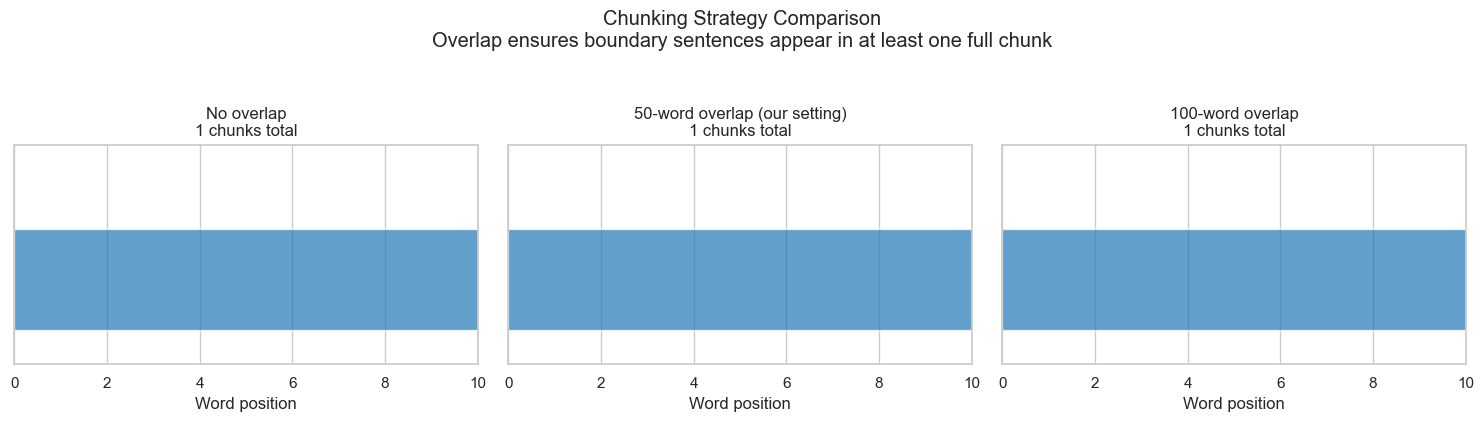

In [13]:
# Show why chunking overlap matters

sample_text = news_df['content'].dropna().iloc[0]
words       = sample_text.split()

print(f"Original document: {len(words)} words\n")

configs = [
    (512, 0,  "No overlap"),
    (512, 50, "50-word overlap (our setting)"),
    (512, 100,"100-word overlap"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (chunk_size, overlap, label) in zip(axes, configs):
    chunks = chunk_text(sample_text, chunk_size=chunk_size, overlap=overlap)
    n      = min(len(chunks), 8)

    # Visualize chunk coverage as blocks
    step = chunk_size - overlap
    for i in range(n):
        start = i * step
        end   = min(start + chunk_size, len(words))
        color = plt.cm.tab10(i / 10)
        ax.barh(
            0, end - start,
            left   = start,
            height = 0.6,
            color  = color,
            alpha  = 0.7,
            label  = f'Chunk {i+1}',
        )

    ax.set_xlim(0, len(words))
    ax.set_ylim(-0.5, 0.8)
    ax.set_xlabel('Word position')
    ax.set_title(f'{label}\n{len(chunks)} chunks total')
    ax.set_yticks([])

plt.suptitle(
    'Chunking Strategy Comparison\n'
    'Overlap ensures boundary sentences appear in at least one full chunk',
    y=1.05
)
plt.tight_layout()
plt.show()

# Show the actual boundary region
if len(words) > 550:
    boundary_no_overlap  = " ".join(words[510:520])
    boundary_with_overlap = " ".join(words[460:520])
    print(f"Without overlap — words at boundary (510-520):")
    print(f"  '{boundary_no_overlap}'")
    print(f"\nWith 50-word overlap — same words appear in full context (460-520):")
    print(f"  '{boundary_with_overlap[:120]}...'")

In [16]:
print("=" * 60)
print("RAG PIPELINE SUMMARY")
print("=" * 60)

print(f"\n📦 VECTOR STORE")
stats = store.get_stats()
print(f"   Chunks stored:     {stats['total_chunks']}")
print(f"   Collection:        {stats['collection_name']}")

print(f"\n🔢 EMBEDDINGS")
print(f"   Model:             {embedder.model_name}")
print(f"   Dimensions:        {embedder.dim}")
print(f"   Similarity metric: Cosine (normalized vectors)")

print(f"\n🔍 RETRIEVAL")
print(f"   Top-k chunks:      5")
print(f"   Min similarity:    0.30")
print(f"   Deduplication:     enabled (>0.95 overlap removed)")

print(f"\n🤖 LLM")
print(f"   Model:             gemini-2.5-flash")
print(f"   Temperature:       0.1 (deterministic)")
print(f"   Max tokens:        1000")
print(f"   History turns:     last 3 (6 messages)")

print(f"\n✅ WHAT RAG ADDS OVER PLAIN LLM:")
print(f"   1. Grounds answers in real, dated documents")
print(f"   2. Provides source citations for every claim")
print(f"   3. Eliminates hallucination of specific figures")
print(f"   4. Enables queries about events after LLM cutoff")
print(f"   5. Filters to company-specific information")

chatbot_obj = globals().get("chatbot", None)

print(f"\n💬 THIS SESSION:")
if chatbot_obj is not None and hasattr(chatbot_obj, "get_session_summary"):
	session = chatbot_obj.get_session_summary()
	print(f"   Questions asked:   {session['question_count']}")
	print(f"   Tickers covered:   {session['tickers_discussed']}")
else:
	print(f"   Questions asked:   N/A")
	print(f"   Tickers covered:   N/A")

print("=" * 60)

RAG PIPELINE SUMMARY

📦 VECTOR STORE
   Chunks stored:     20
   Collection:        notebook_test

🔢 EMBEDDINGS
   Model:             sentence-transformers/all-MiniLM-L6-v2
   Dimensions:        384
   Similarity metric: Cosine (normalized vectors)

🔍 RETRIEVAL
   Top-k chunks:      5
   Min similarity:    0.30
   Deduplication:     enabled (>0.95 overlap removed)

🤖 LLM
   Model:             gemini-2.5-flash
   Temperature:       0.1 (deterministic)
   Max tokens:        1000
   History turns:     last 3 (6 messages)

✅ WHAT RAG ADDS OVER PLAIN LLM:
   1. Grounds answers in real, dated documents
   2. Provides source citations for every claim
   3. Eliminates hallucination of specific figures
   4. Enables queries about events after LLM cutoff
   5. Filters to company-specific information

💬 THIS SESSION:
   Questions asked:   N/A
   Tickers covered:   N/A
